In [79]:
using LinearAlgebra
using Random
using StatsBase
using CairoMakie  
using Revise
# CairoMakie.activate!(inline=true)
CairoMakie.activate!(type = "png", inline=true, px_per_unit=2.0, pt_per_unit=1.0)
using JLD2
using FileIO
using CSV
using GZip
using EM
using RollingFunctions
using HypothesisTests
using ShiftedArrays

In [80]:
filepath = ".."
# include("$(filepath)/code/hmm.jl")
include("$(filepath)/code/util.jl")
include("$(filepath)/code/em_scripts.jl");

In [81]:
results_base = Dict()
results_nogo = Dict()
results_nostay = Dict()
results_noturn = Dict()

loocv_base = Dict()
loocv_nogo = Dict()
loocv_noturn = Dict()
loocv_nostay = Dict()

# Load
for animal in animals
    results_base[animal] = load("../results/hmm_staygo_biases/hmm_staygo_Bgo_Bstay_Bturn_leaf_stay_turn_leafspatial_rewscaled_$(animal).jld2", "results")
    results_noturn[animal] = load("../results/hmm_staygo_biases/hmm_staygo_Bgo_Bstay_leaf_stay_turn_leafspatial_rewscaled_$(animal).jld2", "results")
    results_nogo[animal] = load("../results/hmm_staygo_biases/hmm_staygo_Bstay_Bturn_leaf_stay_turn_leafspatial_rewscaled_$(animal).jld2", "results")
    results_nostay[animal] = load("../results/hmm_staygo_biases/hmm_staygo_Bgo_Bturn_leaf_stay_turn_leafspatial_rewscaled_$(animal).jld2", "results")

    loocv_base[animal] = load("../results/hmm_staygo_biases_loocv/hmm_staygo_Bgo_Bstay_Bturn_leaf_stay_turn_leafspatial_rewscaled_$(animal)_loocv.jld2", "results_loocv")
    loocv_nogo[animal] = load("../results/hmm_staygo_biases_loocv/hmm_staygo_Bstay_Bturn_leaf_stay_turn_leafspatial_rewscaled_$(animal)_loocv.jld2", "results_loocv")
    loocv_noturn[animal] = load("../results/hmm_staygo_biases_loocv/hmm_staygo_Bgo_Bstay_leaf_stay_turn_leafspatial_rewscaled_$(animal)_loocv.jld2", "results_loocv")
    loocv_nostay[animal] = load("../results/hmm_staygo_biases_loocv/hmm_staygo_Bgo_Bturn_leaf_stay_turn_leafspatial_rewscaled_$(animal)_loocv.jld2", "results_loocv")
end

# IAIC Results

senor
3278.989949953393
3275.501620897827
chimi
2096.1830910882154
2094.3637663210247
j16
2492.5874299250436
2482.459057011505
peanut
3518.743873228038
3502.0392551091577
wilbur
2690.3640454716146
2683.697259491436


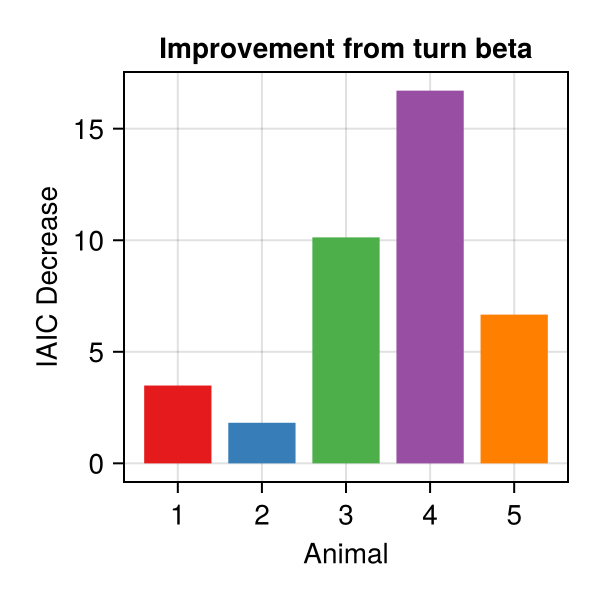

In [82]:
f = Figure(size=(300, 300))
ax = Axis(f[1,1], title="Improvement from turn beta", xlabel="Animal", ylabel="IAIC Decrease")
colors = categorical_colors(:Set1, 5)
for (i, animal) in enumerate(animals)
    r1 = results_noturn[animal]
    r2 = results_base[animal]
    r1_iaic = iaic(r1.x, r1.l, r1.h, r1.betas, r1.sigma)
    r2_iaic = iaic(r2.x, r2.l, r2.h, r2.betas, r2.sigma)
    barplot!(i, r1_iaic - r2_iaic, label=animal, color=colors[i])
    println(animal)
    println(r1_iaic)
    println(r2_iaic)
end
f

senor
3401.91034335052
3275.501620897827
chimi
2129.1591646106494
2094.3637663210247
j16
2558.427926256832
2482.459057011505
peanut
3606.923482669507
3502.0392551091577
wilbur
2769.214092935641
2683.697259491436


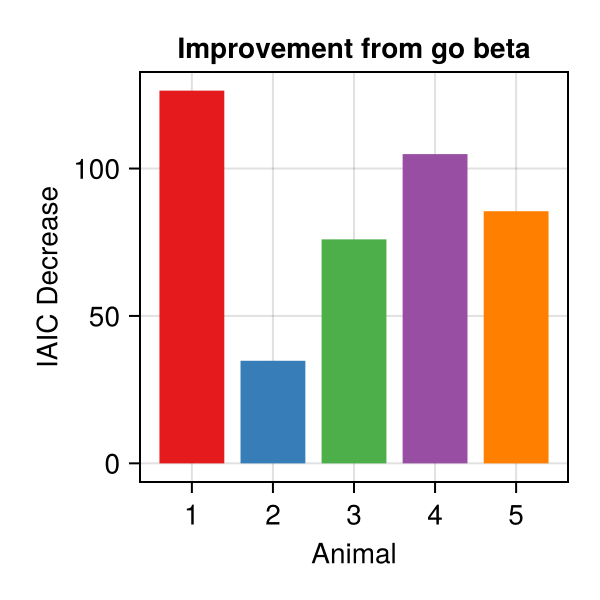

In [83]:
f = Figure(size=(300, 300))
ax = Axis(f[1,1], title="Improvement from go beta", xlabel="Animal", ylabel="IAIC Decrease")
colors = categorical_colors(:Set1, 5)
for (i, animal) in enumerate(animals)
    r1 = results_nogo[animal]
    r2 = results_base[animal]
    r1_iaic = iaic(r1.x, r1.l, r1.h, r1.betas, r1.sigma)
    r2_iaic = iaic(r2.x, r2.l, r2.h, r2.betas, r2.sigma)
    barplot!(i, r1_iaic - r2_iaic, label=animal, color=colors[i])
    println(animal)
    println(r1_iaic)
    println(r2_iaic)
end
f

senor
3413.193759124256
3275.501620897827
chimi
2175.4407316935644
2094.3637663210247
j16
2581.9128403022323
2482.459057011505
peanut
3717.107156249509
3502.0392551091577
wilbur
2830.812225258987
2683.697259491436


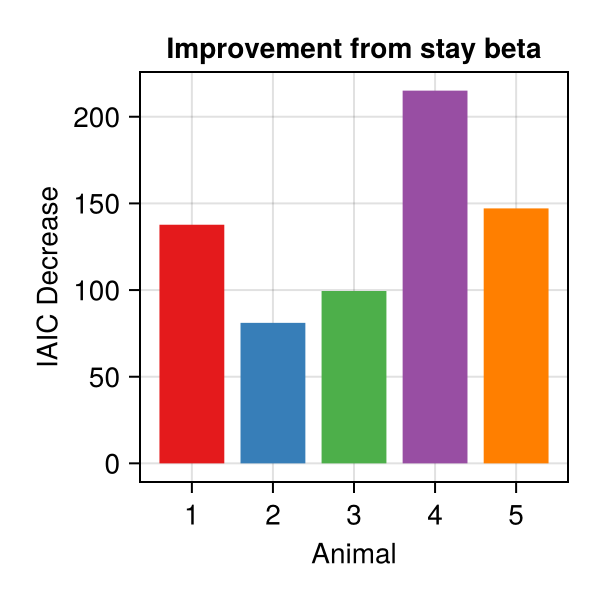

In [84]:
f = Figure(size=(300, 300))
ax = Axis(f[1,1], title="Improvement from stay beta", xlabel="Animal", ylabel="IAIC Decrease")
colors = categorical_colors(:Set1, 5)
for (i, animal) in enumerate(animals)
    r1 = results_nostay[animal]
    r2 = results_base[animal]
    r1_iaic = iaic(r1.x, r1.l, r1.h, r1.betas, r1.sigma)
    r2_iaic = iaic(r2.x, r2.l, r2.h, r2.betas, r2.sigma)
    barplot!(i, r1_iaic - r2_iaic, label=animal, color=colors[i])
    println(animal)
    println(r1_iaic)
    println(r2_iaic)
end
f

# LOO-CV Results

senor: 7.410261799805539
chimi: -3.0503549267964445
j16: 9.36723509843614
peanut: 16.737665671393643
wilbur: 8.129170154314124


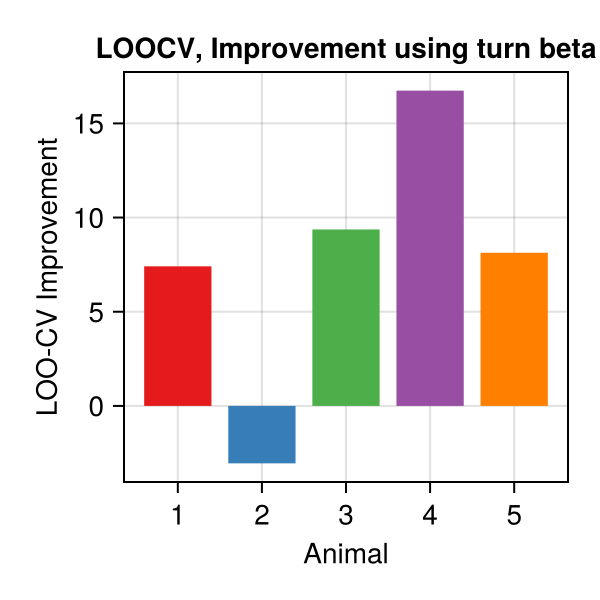

In [85]:
# Higher indicates dependent model is better
f = Figure(size=(300, 300))
ax = Axis(f[1,1], title="LOOCV, Improvement using turn beta", xlabel="Animal", ylabel="LOO-CV Improvement")
colors = categorical_colors(:Set1, 5)
for (i, animal) in enumerate(animals)
    r1 = loocv_noturn[animal]
    r2 = loocv_base[animal]
    barplot!(i, sum(r1) - sum(r2), label=animal, color=colors[i])
    println("$(animal): $(sum(r1) - sum(r2))")
end
# save("figures/loocv_improvement_dependent_model.pdf", f)
f

In [86]:
animal = animals[1]
r1 = loocv_noturn[animal]
r2 = loocv_base[animal]
print(OneSampleTTest(r1, r2))

One sample t-test
-----------------
Population details:
    parameter of interest:   Mean
    value under h_0:         0
    point estimate:          0.67366
    95% confidence interval: (0.2105, 1.137)

Test summary:
    outcome with 95% confidence: reject h_0
    two-sided p-value:           0.0089

Details:
    number of observations:   11
    t-statistic:              3.2410784758862956
    degrees of freedom:       10
    empirical standard error: 0.2078506178208068


In [87]:
animal = animals[2]
r1 = loocv_noturn[animal]
r2 = loocv_base[animal]
print(OneSampleTTest(r1, r2))

One sample t-test
-----------------
Population details:
    parameter of interest:   Mean
    value under h_0:         0
    point estimate:          -0.190647
    95% confidence interval: (-0.289, -0.09226)

Test summary:
    outcome with 95% confidence: reject h_0
    two-sided p-value:           0.0009

Details:
    number of observations:   16
    t-statistic:              -4.130190684759609
    degrees of freedom:       15
    empirical standard error: 0.04615941429249237


In [88]:
animal = animals[3]
r1 = loocv_noturn[animal]
r2 = loocv_base[animal]
print(OneSampleTTest(r1, r2))

One sample t-test
-----------------
Population details:
    parameter of interest:   Mean
    value under h_0:         0
    point estimate:          1.1709
    95% confidence interval: (-0.1994, 2.541)

Test summary:
    outcome with 95% confidence: fail to reject h_0
    two-sided p-value:           0.0831

Details:
    number of observations:   8
    t-statistic:              2.0205377418034365
    degrees of freedom:       7
    empirical standard error: 0.5795013689075813


In [89]:
animal = animals[4]
r1 = loocv_noturn[animal]
r2 = loocv_base[animal]
print(OneSampleTTest(r1, r2))

One sample t-test
-----------------
Population details:
    parameter of interest:   Mean
    value under h_0:         0
    point estimate:          2.09221
    95% confidence interval: (0.319, 3.865)

Test summary:
    outcome with 95% confidence: reject h_0
    two-sided p-value:           0.0269

Details:
    number of observations:   8
    t-statistic:              2.790028499377667
    degrees of freedom:       7
    empirical standard error: 0.749887755408576


In [90]:
animal = animals[5]
r1 = loocv_noturn[animal]
r2 = loocv_base[animal]
print(OneSampleTTest(r1, r2))

One sample t-test
-----------------
Population details:
    parameter of interest:   Mean
    value under h_0:         0
    point estimate:          1.01615
    95% confidence interval: (-0.2275, 2.26)

Test summary:
    outcome with 95% confidence: fail to reject h_0
    two-sided p-value:           0.0946

Details:
    number of observations:   8
    t-statistic:              1.9320395941155306
    degrees of freedom:       7
    empirical standard error: 0.5259448472920665


senor: 136.00099435104676
chimi: 72.3115598107106
j16: 97.4615409972912
peanut: 199.51660326844285
wilbur: 144.00542184726055


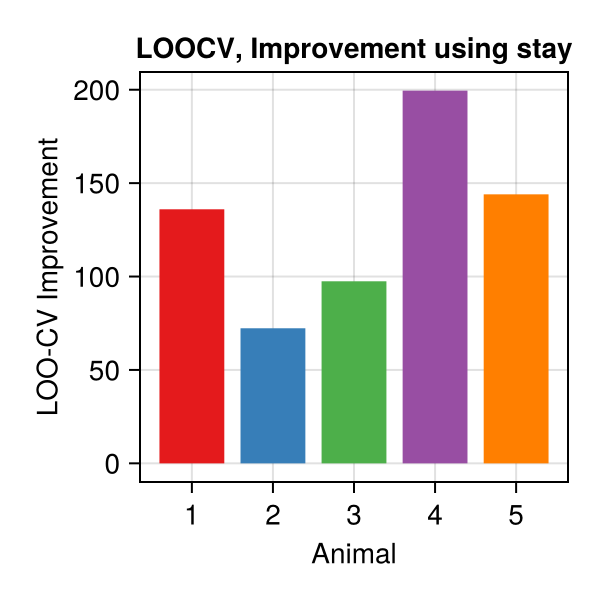

In [91]:
# Higher indicates dependent model is better
f = Figure(size=(300, 300))
ax = Axis(f[1,1], title="LOOCV, Improvement using stay", xlabel="Animal", ylabel="LOO-CV Improvement")
colors = categorical_colors(:Set1, 5)
for (i, animal) in enumerate(animals)
    r1 = loocv_nostay[animal]
    r2 = loocv_base[animal]
    barplot!(i, sum(r1) - sum(r2), label=animal, color=colors[i])
    println("$(animal): $(sum(r1) - sum(r2))")
end
save("figures/loocv_improvement_stay_beta.pdf", f)
f

In [92]:
animal = animals[1]
r1 = loocv_nostay[animal]
r2 = loocv_base[animal]
print(OneSampleTTest(r1, r2))

One sample t-test
-----------------
Population details:
    parameter of interest:   Mean
    value under h_0:         0
    point estimate:          12.3637
    95% confidence interval: (5.762, 18.97)

Test summary:
    outcome with 95% confidence: reject h_0
    two-sided p-value:           0.0019

Details:
    number of observations:   11
    t-statistic:              4.172746789943607
    degrees of freedom:       10
    empirical standard error: 2.962970767596735


In [93]:
animal = animals[2]
r1 = loocv_nostay[animal]
r2 = loocv_base[animal]
print(OneSampleTTest(r1, r2))

One sample t-test
-----------------
Population details:
    parameter of interest:   Mean
    value under h_0:         0
    point estimate:          4.51947
    95% confidence interval: (1.905, 7.134)

Test summary:
    outcome with 95% confidence: reject h_0
    two-sided p-value:           0.0022

Details:
    number of observations:   16
    t-statistic:              3.6850076522005515
    degrees of freedom:       15
    empirical standard error: 1.2264486032940831


In [94]:
animal = animals[3]
r1 = loocv_nostay[animal]
r2 = loocv_base[animal]
print(OneSampleTTest(r1, r2))

One sample t-test
-----------------
Population details:
    parameter of interest:   Mean
    value under h_0:         0
    point estimate:          12.1827
    95% confidence interval: (6.268, 18.1)

Test summary:
    outcome with 95% confidence: reject h_0
    two-sided p-value:           0.0018

Details:
    number of observations:   8
    t-statistic:              4.870741784755462
    degrees of freedom:       7
    empirical standard error: 2.5011986188204487


In [95]:
animal = animals[4]
r1 = loocv_nostay[animal]
r2 = loocv_base[animal]
print(OneSampleTTest(r1, r2))

One sample t-test
-----------------
Population details:
    parameter of interest:   Mean
    value under h_0:         0
    point estimate:          24.9396
    95% confidence interval: (12.11, 37.77)

Test summary:
    outcome with 95% confidence: reject h_0
    two-sided p-value:           0.0025

Details:
    number of observations:   8
    t-statistic:              4.596416672567148
    degrees of freedom:       7
    empirical standard error: 5.42587349780592


In [96]:
animal = animals[5]
r1 = loocv_nostay[animal]
r2 = loocv_base[animal]
print(OneSampleTTest(r1, r2))

One sample t-test
-----------------
Population details:
    parameter of interest:   Mean
    value under h_0:         0
    point estimate:          18.0007
    95% confidence interval: (11.85, 24.15)

Test summary:
    outcome with 95% confidence: reject h_0
    two-sided p-value:           0.0002

Details:
    number of observations:   8
    t-statistic:              6.924866923752543
    degrees of freedom:       7
    empirical standard error: 2.599425798229363


senor: 173.3690655499031
chimi: 29.07895483862376
j16: 65.24954524828718
peanut: 114.92283501771362
wilbur: 79.71335154776034


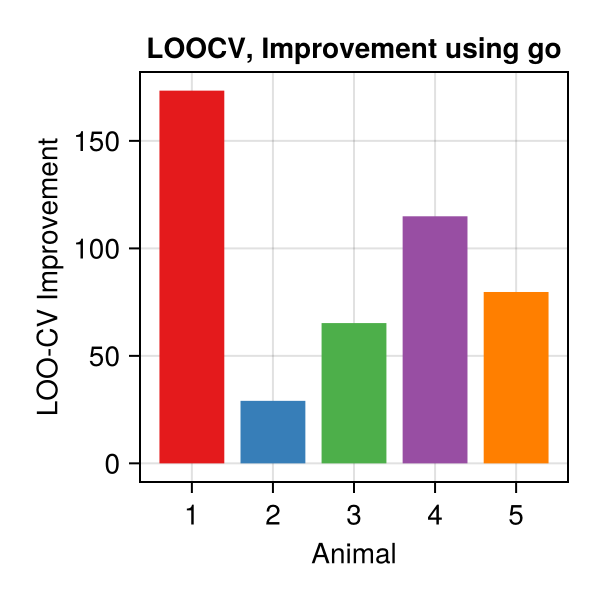

In [97]:
# Higher indicates dependent model is better
f = Figure(size=(300, 300))
ax = Axis(f[1,1], title="LOOCV, Improvement using go", xlabel="Animal", ylabel="LOO-CV Improvement")
colors = categorical_colors(:Set1, 5)
for (i, animal) in enumerate(animals)
    r1 = loocv_nogo[animal]
    r2 = loocv_base[animal]
    barplot!(i, sum(r1) - sum(r2), label=animal, color=colors[i])
    println("$(animal): $(sum(r1) - sum(r2))")
end
save("figures/loocv_improvement_go_beta.pdf", f)
f

In [98]:
animal = animals[1]
r1 = loocv_nogo[animal]
r2 = loocv_base[animal]
print(OneSampleTTest(r1, r2))

One sample t-test
-----------------
Population details:
    parameter of interest:   Mean
    value under h_0:         0
    point estimate:          15.7608
    95% confidence interval: (11.06, 20.46)

Test summary:
    outcome with 95% confidence: reject h_0
    two-sided p-value:           <1e-04

Details:
    number of observations:   11
    t-statistic:              7.475123532261157
    degrees of freedom:       10
    empirical standard error: 2.108436612837189


In [99]:
animal = animals[2]
r1 = loocv_nogo[animal]
r2 = loocv_base[animal]
print(OneSampleTTest(r1, r2))

One sample t-test
-----------------
Population details:
    parameter of interest:   Mean
    value under h_0:         0
    point estimate:          1.81743
    95% confidence interval: (-0.4804, 4.115)

Test summary:
    outcome with 95% confidence: fail to reject h_0
    two-sided p-value:           0.1125

Details:
    number of observations:   16
    t-statistic:              1.6858463236765027
    degrees of freedom:       15
    empirical standard error: 1.078054773966879


In [100]:
animal = animals[3]
r1 = loocv_nogo[animal]
r2 = loocv_base[animal]
print(OneSampleTTest(r1, r2))

One sample t-test
-----------------
Population details:
    parameter of interest:   Mean
    value under h_0:         0
    point estimate:          8.15619
    95% confidence interval: (4.099, 12.21)

Test summary:
    outcome with 95% confidence: reject h_0
    two-sided p-value:           0.0021

Details:
    number of observations:   8
    t-statistic:              4.75405569796091
    degrees of freedom:       7
    empirical standard error: 1.7156284390050878


In [101]:
animal = animals[4]
r1 = loocv_nogo[animal]
r2 = loocv_base[animal]
print(OneSampleTTest(r1, r2))

One sample t-test
-----------------
Population details:
    parameter of interest:   Mean
    value under h_0:         0
    point estimate:          14.3654
    95% confidence interval: (8.178, 20.55)

Test summary:
    outcome with 95% confidence: reject h_0
    two-sided p-value:           0.0009

Details:
    number of observations:   8
    t-statistic:              5.490189520211075
    degrees of freedom:       7
    empirical standard error: 2.6165498156905156


In [102]:
animal = animals[5]
r1 = loocv_nogo[animal]
r2 = loocv_base[animal]
print(OneSampleTTest(r1, r2))

One sample t-test
-----------------
Population details:
    parameter of interest:   Mean
    value under h_0:         0
    point estimate:          9.96417
    95% confidence interval: (2.527, 17.4)

Test summary:
    outcome with 95% confidence: reject h_0
    two-sided p-value:           0.0158

Details:
    number of observations:   8
    t-statistic:              3.168063315644589
    degrees of freedom:       7
    empirical standard error: 3.145192488503888
